# Example: Reading and Analyzing GRMONTY Spectral Energy Distributions

This notebook demonstrates how to read, process, and analyze spectral energy distribution (SED) outputs produced by **GPUmonty** simulations.

The main goals of this example are:
- To load GPUmonty `.spec` files using `astropy.io.ascii`
- To convert the tabulated quantities into physical units
- To reconstruct the spectral luminosity \( \nu L_\nu \) for multiple viewing angles

## What this cell does

The code cell below defines a helper function, `grmonty(file)`, which:
1. Reads a GRMONTY SED file with no header.
2. Extracts frequency bins and converts them to physical frequencies.
3. Builds arrays of luminosities for six viewing angles, converting from solar luminosities to cgs units.
5. Returns the frequency array and luminosity arrays for plotting

The notebook also defines the solid-angle weights (`domega_array`) associated with each of the six angular bins, which are typically used when computing angle-averaged spectra.

This setup provides a minimal, reproducible example for inspecting GRMONTY outputs and serves as a starting point for plotting spectra, comparing runs, or integrating over angles.

In [15]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt

def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty.
    
    Returns:
        nu: Frequency array
        ll: Luminosity array (log10)
        tauabs: Absorption optical depth
        domega: Array of solid angles for each theta bin
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27

    # 1. Parse the header for dOmega
    domega_arr = None
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("# dOmega:"):
                # Split by colon to get the numbers, then split by space
                parts = line.split(':')[1].strip().split()
                domega_arr = np.array([np.float64(x) for x in parts])
                break
    
    # Check if dOmega was found; if not, you might want a default or error
    if domega_arr is None:
        print(f"Warning: No dOmega header found in {file}")

    # 2. Read the numerical data
    # format='no_header' treats lines starting with # as comments, 
    # so our new header won't break this.
    s = ascii.read(file, format='no_header')

    # Array conversions for luminosity values (log10)
    # Note: This hardcoding of 6 bins assumes N_THBINS is always 6.
    # If N_THBINS changes, this section needs to be dynamic based on domega_arr.size
    ll = np.zeros((6, len(s))) 
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)
    
    tauabs = np.zeros((6, len(s)))
    tauabs[0] = np.array(s['col3'])     
    tauabs[1] = np.array(s['col9'])
    tauabs[2] = np.array(s['col15'])
    tauabs[3] = np.array(s['col21'])
    tauabs[4] = np.array(s['col27'])
    tauabs[5] = np.array(s['col33'])

    # Compute frequency (nu) values
    # The C code outputs log10(energy), so we convert back
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))

    return nu, ll, tauabs, domega_arr

# Example usage:
nu, nuLnu, tauabs, domega_array = grmonty('../output/sane_iharm.spec')
# print("Read dOmega:", domega_array)

Plotting the spectrum

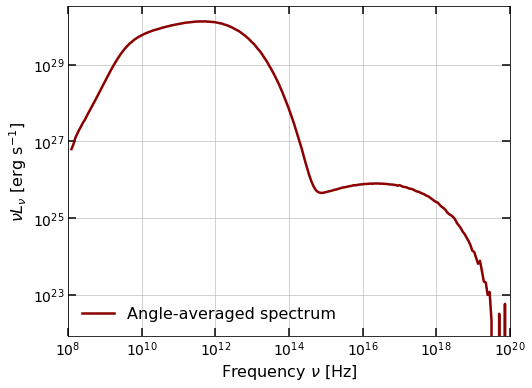

In [16]:
nuLnu_all = (nuLnu * domega_array[:, None] / (4 * np.pi)).sum(axis=0)

plt.figure(figsize=(7.5, 5.5))

plt.loglog(
    nu,
    nuLnu_all,
    linewidth=2.5,
    label=r'Angle-averaged spectrum',
    color='darkred'
)

plt.xlim(1e8, 1e20)

plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=16)
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=16)

plt.legend(frameon=False, fontsize=16)

plt.grid(which='major', linestyle='-', alpha=0.7)
plt.grid(which='minor', linestyle=':', alpha=0.7)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=14,
    top=True,
    right=True
)

plt.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.2,
    top=True,
    right=True
)

plt.tight_layout()
plt.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [19]:
import h5py
M_SQRT2 = np.sqrt(2)
EE = 4.80320680e-10  # Electron charge in cgs
ME = 9.1093826e-28 # Electron mass in grams
CL = 2.99792458e10   # Speed of light in cm/s
JCST = M_SQRT2 * EE**3 / (27 * ME * CL**2)
CST = 1.88774862536  # 2^(11/12)
CL = 2.99792458e10  # Speed of light in cm/s
ME = 9.1093826e-28  # Electron mass in grams
HPL = 6.6260693e-27
THETAE_MIN = 0.3

# Open the HDF5 file
with h5py.File('../../igrmonty_scattering/spectrum.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    LSUN = 3.827e33
    # Extract the datasets 'lnu' and 'nulnu'
    nu_igr = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_igr = output_group['nuLnu'][:] * LSUN
    dOmega_igr = output_group['dOmega'][:]
    
with h5py.File('../../igrmonty_scattering/spectrum.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    LSUN = 3.827e33
    # Extract the datasets 'lnu' and 'nulnu'
    nu_igr_bef = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_igr_bef = output_group['nuLnu'][:] * LSUN
    dOmega_igr_bef = output_group['dOmega'][:]

/tmp/ipykernel_17072/3754158404.py:37: RuntimeWarning: divide by zero encountered in divide
  diff = np.abs(nuLnu_avg - y_igr_interp) / y_igr_interp
/tmp/ipykernel_17072/3754158404.py:37: RuntimeWarning: invalid value encountered in divide
  diff = np.abs(nuLnu_avg - y_igr_interp) / y_igr_interp


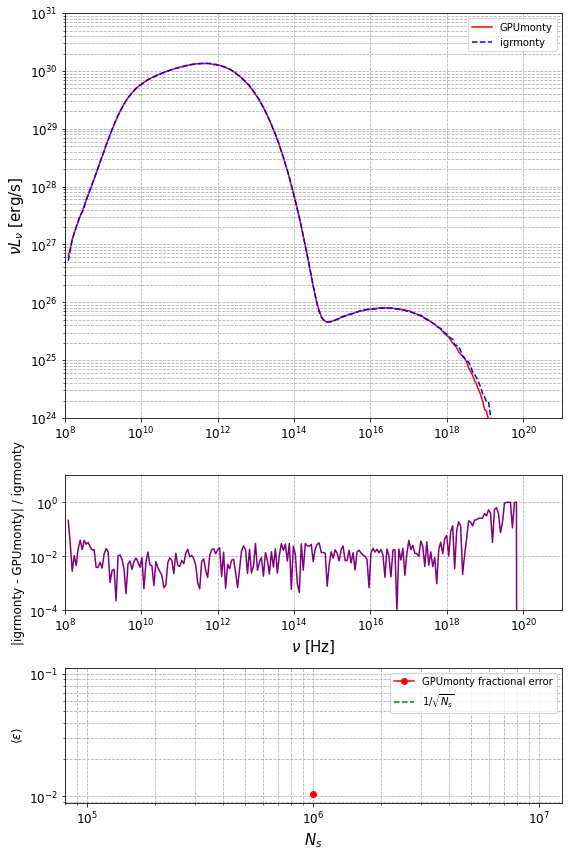

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- Top panel: averaged spectrum ---
nuLnu_avg = (nuLnu * domega_array[:, None] / (4 * np.pi)).sum(0)
nuLnu_avg_igrmonty = (nuLnu_igr.sum(0) * dOmega_igr / (4 * np.pi)).sum(1)
nuLnu_avg_igrmonty_bef = (nuLnu_igr_bef.sum(0) * dOmega_igr_bef / (4 * np.pi)).sum(1)

# --- Frequency range for masking (optional, for fractional error calculation) ---
numin = 1e8
numax = 1e16
mask = (nu >= numin) & (nu <= numax)
nu_masked = nu[mask]

# --- Prepare figure with gridspec ---
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1])

# --- Panel 1: spectra ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(nu, nuLnu_avg, linestyle='-', color='red', label='GPUmonty')
ax1.plot(nu_igr, nuLnu_avg_igrmonty, linestyle='--', color='blue', label='igrmonty')
#ax1.plot(nu_igr_bef, nuLnu_avg_igrmonty_bef, linestyle='--', color='purple', label='igrmonty')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\nu L_\nu$ [erg/s]", fontsize=15)
ax1.set_xlim(1e8, 1e21)
ax1.set_ylim(1e24, 1e31)
ax1.grid(True, which="both", ls="--")
ax1.legend()
ax1.tick_params(axis='both', which='major', labelsize=12)

# --- Panel 2: relative difference ---
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
y_igr_interp = np.interp(nu, nu_igr, nuLnu_avg_igrmonty)
diff = np.abs(nuLnu_avg - y_igr_interp) / y_igr_interp
diff = np.nan_to_num(diff, nan=1e-40, posinf=1e-40, neginf=1e-40)
ax2.plot(nu, diff, color='purple')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r"$\nu$ [Hz]", fontsize=15)
ax2.set_ylabel("|igrmonty - GPUmonty| / igrmonty", fontsize=12)
ax2.set_ylim(1e-4, 1e1)
ax2.grid(True, which="both", ls="--")
ax2.tick_params(axis='both', which='major', labelsize=12)
#ax2.axvline(4e8)
# --- Panel 3: fractional error vs Ns (example with multiple N_s datasets) ---
ax3 = fig.add_subplot(gs[2, 0])
Ns_array = np.array([1e6])
y_list = [nuLnu]  # your simulation outputs
epsilon_avg_list = []

for y_sim in y_list:
    y_simdata = (y_sim * domega_array[:, None] / (4 * np.pi)).sum(0)
    y_igr_interp = np.interp(nu, nu_igr, nuLnu_avg_igrmonty)
    y_sim_masked = y_simdata[mask]
    y_igr_masked = y_igr_interp[mask]
    frac_error = np.abs(y_sim_masked - y_igr_masked) / y_igr_masked
    frac_error = np.nan_to_num(frac_error, nan=1e-40, posinf=1e-40, neginf=1e-40)
    dlnnu = np.log(nu_masked[1:] / nu_masked[:-1])
    epsilon_avg = np.sum(frac_error[1:] * dlnnu) / np.log(numax/numin)
    epsilon_avg_list.append(epsilon_avg)

epsilon_avg_list = np.array(epsilon_avg_list)

# Plot fractional error vs Ns
ax3.plot(Ns_array, epsilon_avg_list, 'o-', color='red', label='GPUmonty fractional error')
ax3.plot(Ns_array, epsilon_avg_list[0]*(Ns_array[0]/Ns_array)**0.5, '--', color='green', label=r'1/$\sqrt{N_s}$')

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel(r"$N_s$", fontsize=15)
ax3.set_ylabel(r"$\langle \epsilon \rangle$", fontsize=12)
ax3.grid(True, which="both", ls="--")
ax3.legend()
ax3.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
#plt.savefig("spectra_comparison_full.png", dpi=300)
plt.show()